# Gradient Boosting Regressor - Yacht Hydrodynamics

## 1. Project Overview

This project implements a **Gradient Boosting Regressor** to predict the **residuary resistance** of sailing yachts from hydrodynamic and hull-design characteristics.

Gradient Boosting builds decision trees sequentially. Each new tree focuses on reducing the prediction errors made by the existing ensemble. By combining many weak learners, the algorithm can capture complex nonlinear relationships in regression data.

The workflow includes dataset exploration, data-quality checks, exploratory data analysis, train-test splitting, Gradient Boosting model training, regression evaluation, prediction visualization, residual analysis, and feature importance analysis.

**Target variable:** `Rr`


## 2. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 3. Load Dataset

In [2]:
df = pd.read_csv("yacht_hydrodynamics.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (308, 7)


,LC,PC,L/D,B/Dr,L/B,Fr,Rr
0,-2.3,0.568,4.78,3.99,3.17,0.125,0.11
1,-2.3,0.568,4.78,3.99,3.17,0.150,0.27
2,-2.3,0.568,4.78,3.99,3.17,0.175,0.47
3,-2.3,0.568,4.78,3.99,3.17,0.200,0.78
4,-2.3,0.568,4.78,3.99,3.17,0.225,1.18


## 4. Explore Dataset

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
display(df.describe().T)

Columns:
['LC', 'PC', 'L/D', 'B/Dr', 'L/B', 'Fr', 'Rr']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   LC      308 non-null    float64
 1   PC      308 non-null    float64
 2   L/D     308 non-null    float64
 3   B/Dr    308 non-null    float64
 4   L/B     308 non-null    float64
 5   Fr      308 non-null    float64
 6   Rr      308 non-null    float64
dtypes: float64(7)
memory usage: 17.0 KB

Statistical summary:


,count,mean,std,min,25%,50%,75%,max
LC,308.0,-2.381818,1.513219,-5.000,-2.4000,-2.3000,-2.300,0.00
PC,308.0,0.564136,0.023290,0.530,0.5460,0.5650,0.574,0.60
L/D,308.0,4.788636,0.253057,4.340,4.7700,4.7800,5.100,5.14
B/Dr,308.0,3.936818,0.548193,2.810,3.7500,3.9550,4.170,5.35
L/B,308.0,3.206818,0.247998,2.730,3.1500,3.1500,3.510,3.64
Fr,308.0,0.287500,0.100942,0.125,0.2000,0.2875,0.375,0.45
Rr,308.0,10.495357,15.160490,0.010,0.7775,3.0650,12.815,62.42


## 5. Missing Values and Duplicates

In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
LC      0
PC      0
L/D     0
B/Dr    0
L/B     0
Fr      0
Rr      0
dtype: int64

Duplicate rows: 0


## 6. Data Cleaning

In [5]:
# Remove exact duplicate rows, if any
df = df.drop_duplicates().copy()

# The dataset is numerical. If any missing values exist, use median imputation.
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("Cleaned dataset shape:", df.shape)
print("\nRemaining missing values:")
print(df.isnull().sum())

Cleaned dataset shape: (308, 7)

Remaining missing values:
LC      0
PC      0
L/D     0
B/Dr    0
L/B     0
Fr      0
Rr      0
dtype: int64


## 7. Exploratory Data Analysis

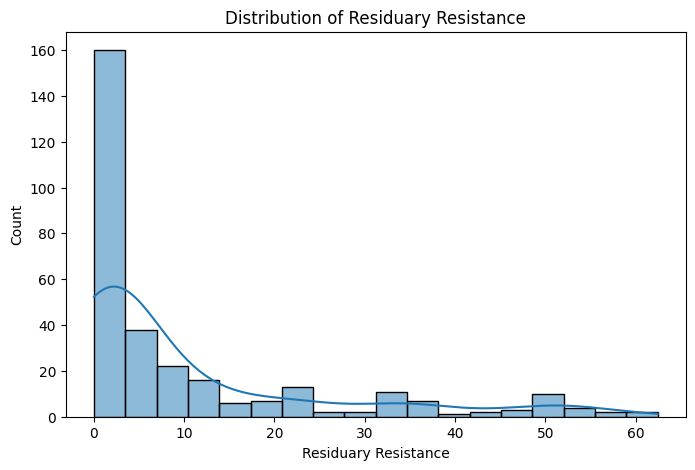

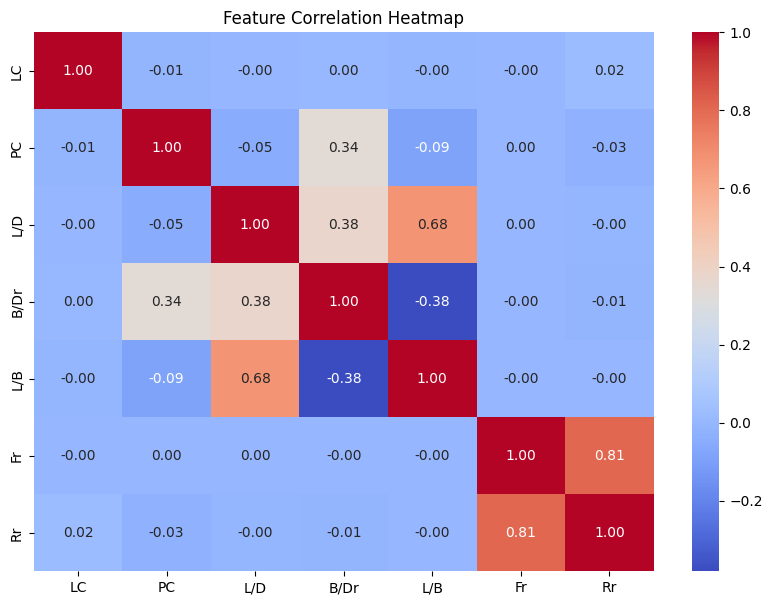

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Rr'], kde=True)
plt.title("Distribution of Residuary Resistance")
plt.xlabel("Residuary Resistance")
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

## 8. Prepare Features and Target

In [7]:
X = df.drop(columns=['Rr'])
y = df['Rr']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

Feature matrix shape: (308, 6)
Target shape: (308,)

Features:
['LC', 'PC', 'L/D', 'B/Dr', 'L/B', 'Fr']


## 9. Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 246
Testing samples : 62


## 10. Train Gradient Boosting Regressor

Gradient Boosting creates an ensemble of decision trees sequentially. Each tree attempts to correct the residual errors produced by the previous trees.

Unlike distance-based algorithms such as KNN and SVR, tree-based Gradient Boosting does not require feature scaling.


In [9]:
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("Gradient Boosting Regressor training complete.")

Gradient Boosting Regressor training complete.


## 11. Make Predictions

In [10]:
y_pred = model.predict(X_test)

print("Predictions generated:", len(y_pred))

Predictions generated: 62


## 12. Model Evaluation

The model is evaluated using standard regression metrics:

- **MAE:** Average absolute prediction error.
- **MSE:** Average squared prediction error.
- **RMSE:** Prediction error expressed in the same units as the target.
- **R² Score:** Proportion of variance in the target explained by the model.


In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 55)
print("Gradient Boosting Regressor Evaluation Metrics")
print("=" * 55)
print(f"Mean Absolute Error (MAE) : {mae:,.2f}")
print(f"Mean Squared Error (MSE)  : {mse:,.2f}")
print(f"Root Mean Squared Error   : {rmse:,.2f}")
print(f"R² Score                  : {r2:.4f}")
print("=" * 55)

Gradient Boosting Regressor Evaluation Metrics
Mean Absolute Error (MAE) : 0.26
Mean Squared Error (MSE)  : 0.32
Root Mean Squared Error   : 0.57
R² Score                  : 0.9978


## 13. Actual vs Predicted Values

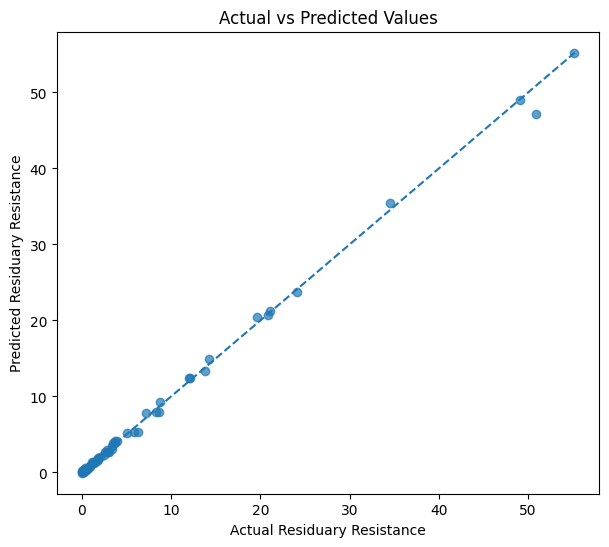

In [12]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot([minimum, maximum], [minimum, maximum], linestyle='--')
plt.xlabel("Actual Residuary Resistance")
plt.ylabel("Predicted Residuary Resistance")
plt.title("Actual vs Predicted Values")
plt.show()

## 14. Residual Analysis

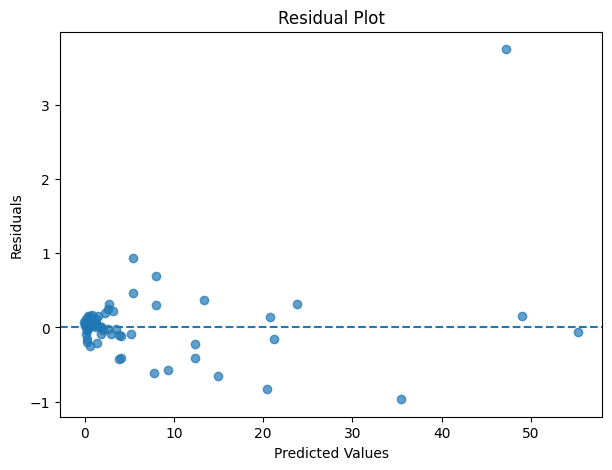

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## 15. Feature Importance

,Feature,Importance
5,Fr,0.988535
1,PC,0.006450
3,B/Dr,0.002105
0,LC,0.002078
4,L/B,0.000676
2,L/D,0.000155


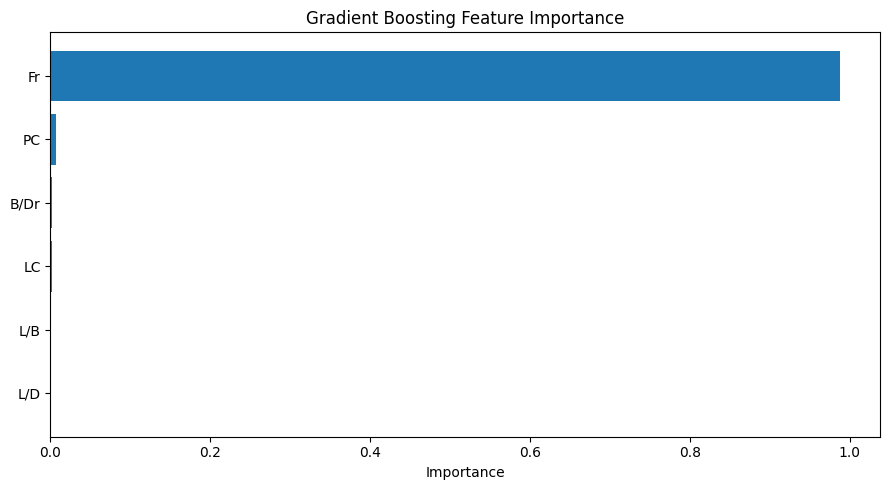

In [14]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

display(feature_importance)

plt.figure(figsize=(9, 5))
importance_plot = feature_importance.sort_values('Importance')
plt.barh(importance_plot['Feature'], importance_plot['Importance'])
plt.xlabel("Importance")
plt.title("Gradient Boosting Feature Importance")
plt.tight_layout()
plt.show()

## 16. Key Findings

- The Gradient Boosting Regressor achieved excellent predictive performance on the Yacht Hydrodynamics dataset.
- The model achieved a **Mean Absolute Error (MAE) of 0.26**, indicating a very low average absolute difference between actual and predicted residuary resistance values.
- The **Root Mean Squared Error (RMSE) was 0.57**, demonstrating that prediction errors were generally small.
- The model achieved an exceptional **R² score of 0.9978**, explaining approximately **99.78% of the variance** in residuary resistance on the test dataset.
- Feature importance analysis showed that the **Froude number (`Fr`)** was overwhelmingly the most influential feature in predicting residuary resistance.
- The **prismatic coefficient (`PC`)** provided a small secondary contribution, while the remaining hull-design features had considerably lower importance according to the trained model.
- The dominance of `Fr` indicates that the Gradient Boosting model found a very strong predictive relationship between the Froude number and residuary resistance in this dataset.
- The relatively low importance of the remaining features does not imply that they have no physical significance; rather, they provided less additional predictive information to this particular trained model.
- Overall, Gradient Boosting effectively captured the nonlinear relationships present in the dataset and produced highly accurate predictions on the selected train-test split.

## 17. Conclusion

This project demonstrated the implementation of a **Gradient Boosting Regressor** for predicting the residuary resistance of sailing yachts using hydrodynamic and hull-design characteristics.

The model achieved excellent performance, with an **MAE of 0.26**, an **RMSE of 0.57**, and an **R² score of 0.9978**. The R² result indicates that the model explained approximately **99.78% of the variance** in residuary resistance on the test dataset.

Feature importance analysis identified the **Froude number (`Fr`)** as the dominant predictor, with the prismatic coefficient (`PC`) making a smaller contribution. This demonstrates Gradient Boosting's ability to identify and leverage strong nonlinear relationships between input features and the target variable.

Overall, the results show that Gradient Boosting is highly effective for this structured regression problem. Since the dataset contains only 308 observations, the reported performance should be interpreted as performance on the selected train-test split. Cross-validation could be introduced in future work to provide a more robust estimate of the model's generalization performance.